<a href="https://colab.research.google.com/github/GeemaInduruwage/computer-vision-assignment-1/blob/main/Question_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Question 10**

Image loaded successfully with shape: (217, 181)


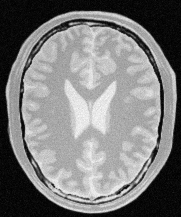

Original Image


In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load the grayscale image
img_path = '/content/brain_proton_density_slice.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Could not load image from {img_path}")
else:
    print(f"Image loaded successfully with shape: {img.shape}")
    cv2_imshow(img)
    print("Original Image")

### (a) Python function to manually implement a bilateral filter

In [2]:
def bilateral_filter_manual(image, diameter, sigma_s, sigma_r):
    H, W = image.shape
    output = np.zeros(image.shape, dtype=np.float32)
    padded_image = np.pad(image, diameter // 2, mode='reflect').astype(np.float32)

    # Precompute spatial and intensity Gaussian weights
    spatial_weights = np.zeros((diameter, diameter), dtype=np.float32)
    center = diameter // 2
    for i in range(diameter):
        for j in range(diameter):
            dx = i - center
            dy = j - center
            spatial_weights[i, j] = np.exp(-0.5 * (dx**2 + dy**2) / (sigma_s**2))

    for i in range(H):
        for j in range(W):
            # Extract neighborhood
            neighborhood = padded_image[i : i + diameter, j : j + diameter]

            # Calculate intensity difference
            intensity_diff = neighborhood - image[i, j]

            # Compute range weights
            range_weights = np.exp(-0.5 * (intensity_diff**2) / (sigma_r**2))

            # Combine spatial and range weights
            combined_weights = spatial_weights * range_weights

            # Normalize and apply filter
            normalization_factor = np.sum(combined_weights)
            if normalization_factor == 0:
                output[i, j] = image[i, j]
            else:
                output[i, j] = np.sum(neighborhood * combined_weights) / normalization_factor

    return np.uint8(output)

print("Bilateral filter manual implementation function defined.")

Bilateral filter manual implementation function defined.


### (b) Apply Gaussian smoothing using OpenCV's `cv.GaussianBlur()`

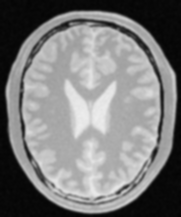

Gaussian Blurred Image (OpenCV)


In [3]:
# (b) Gaussian smoothing
gaussian_blurred_img = cv2.GaussianBlur(img, (5, 5), 0)
cv2_imshow(gaussian_blurred_img)
print("Gaussian Blurred Image (OpenCV)")

### (c) Bilateral filtering using OpenCV's `cv.bilateralFilter()`

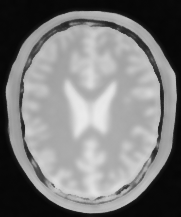

Bilateral Filtered Image (OpenCV)


In [4]:
# (c) Bilateral filtering using OpenCV
diameter = 9  # Diameter of the pixel neighborhood
sigma_color = 75 # Filter sigma in the color space
sigma_space = 75 # Filter sigma in the coordinate space

opencv_bilateral_img = cv2.bilateralFilter(img, diameter, sigma_color, sigma_space)
cv2_imshow(opencv_bilateral_img)
print("Bilateral Filtered Image (OpenCV)")

### (d) Your manually implemented bilateral filter from part (a).

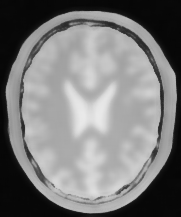

Bilateral Filtered Image (Manual Implementation)


In [5]:
# (d) Apply the manually implemented bilateral filter
diameter_manual = 9
sigma_s_manual = 75
sigma_r_manual = 75

# Note: Manual implementation can be slow for larger images/diameters.
# Consider reducing diameter or image size for quicker execution if needed.
manual_bilateral_img = bilateral_filter_manual(img, diameter_manual, sigma_s_manual, sigma_r_manual)
cv2_imshow(manual_bilateral_img)
print("Bilateral Filtered Image (Manual Implementation)")